In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import cv2

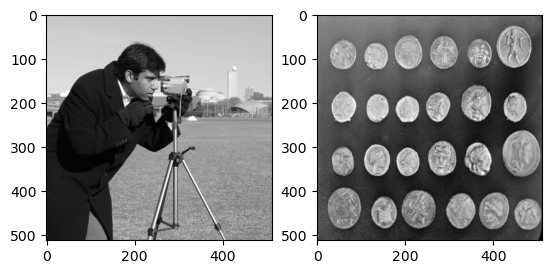

In [19]:
cam_img = data.camera().astype(float)   # photographer
coin_img = data.coins().astype(float)    # coins

coin_img = np.array(cv2.resize(coin_img, cam_img.shape))


plt.subplot(121)
plt.imshow(cam_img, cmap='grey')

plt.subplot(122)
plt.imshow(coin_img, cmap='grey')

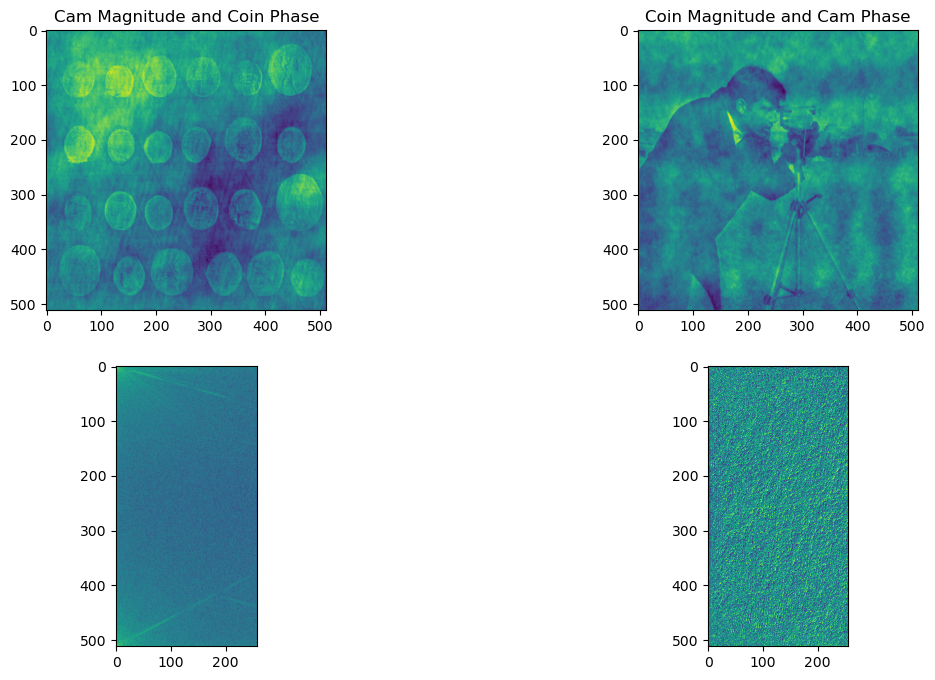

In [42]:
fft_cam = np.fft.rfft2(cam_img)
fft_coin = np.fft.rfft2(coin_img)

# Shift
# fft_cam = np.fft.fftshift(fft_cam)
# fft_coin = np.fft.fftshift(fft_coin)

mag_cam, phase_cam = np.abs(fft_cam), np.angle(fft_cam)
mag_coin, phase_coin = np.abs(fft_coin), np.angle(fft_coin)

hyprid_cam = np.fft.irfft2(mag_cam * np.exp(1j * phase_coin)).real
hyprid_coin = np.fft.irfft2(mag_coin * np.exp(1j * phase_cam))

fig, axs = plt.subplots(2, 2, figsize=(14, 8))


axs[0, 0].imshow(hyprid_cam.real)
axs[0, 0].set_title("Cam Magnitude and Coin Phase")
axs[0, 1].imshow(hyprid_coin.real)
axs[0, 1].set_title("Coin Magnitude and Cam Phase")

axs[1, 0].imshow(np.log1p(mag_cam))
axs[1, 1].imshow(phase_cam)

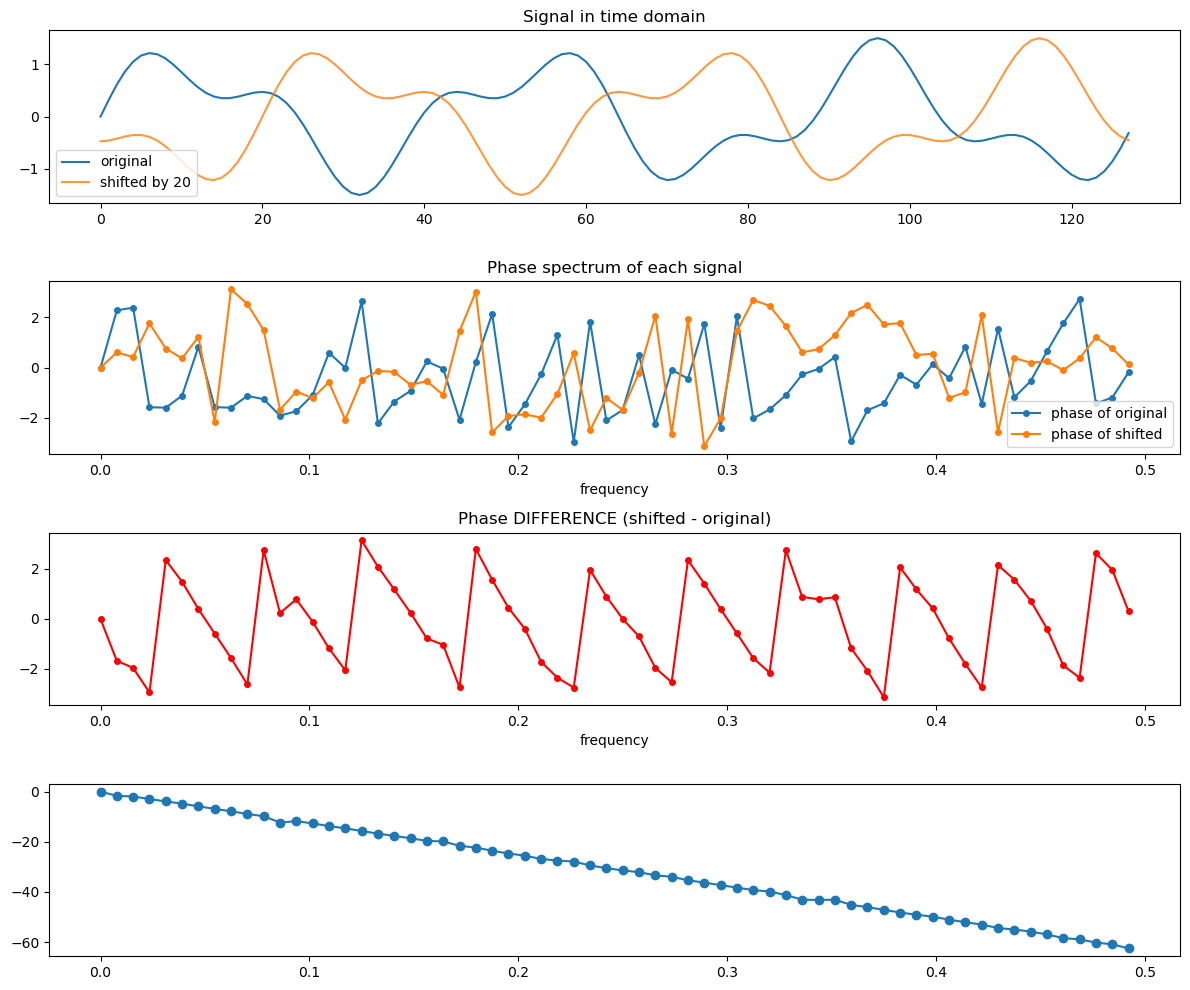

In [58]:
# Simple 1D signal
N = 128
t = np.arange(N)

# Original signal - sum of a few frequencies
signal = np.sin(2 * np.pi * 3 * t / N) + 0.5 * np.sin(2 * np.pi * 7 * t / N)

# Shift it by 20 samples (circular shift)
shift = 20
signal_shifted = np.roll(signal, shift)

# FFT of both
F1 = np.fft.fft(signal)
F2 = np.fft.fft(signal_shifted)

freqs = np.fft.fftfreq(N)

# Phase of both
phase1 = np.angle(F1)
phase2 = np.angle(F2)

# Phase DIFFERENCE
phase_diff = np.angle(F2 * np.conj(F1))  # we'll talk about this later
phase_diff_unwrapped = np.unwrap(phase_diff)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(t, signal, label='original')
axes[0].plot(t, signal_shifted, label=f'shifted by {shift}', alpha=0.8)
axes[0].set_title('Signal in time domain')
axes[0].legend()

axes[1].plot(freqs[:N//2], phase1[:N//2], 'o-', label='phase of original', markersize=4)
axes[1].plot(freqs[:N//2], phase2[:N//2], 'o-', label='phase of shifted', markersize=4)
axes[1].set_title('Phase spectrum of each signal')
axes[1].set_xlabel('frequency')
axes[1].legend()

axes[2].plot(freqs[:N//2], phase_diff[:N//2], 'o-', color='red', markersize=4)
axes[2].set_title('Phase DIFFERENCE (shifted - original)')
axes[2].set_xlabel('frequency')

axes[3].plot(freqs[:N//2], np.unwrap(phase_diff[:N//2]), 'o-')

plt.tight_layout()
plt.show()

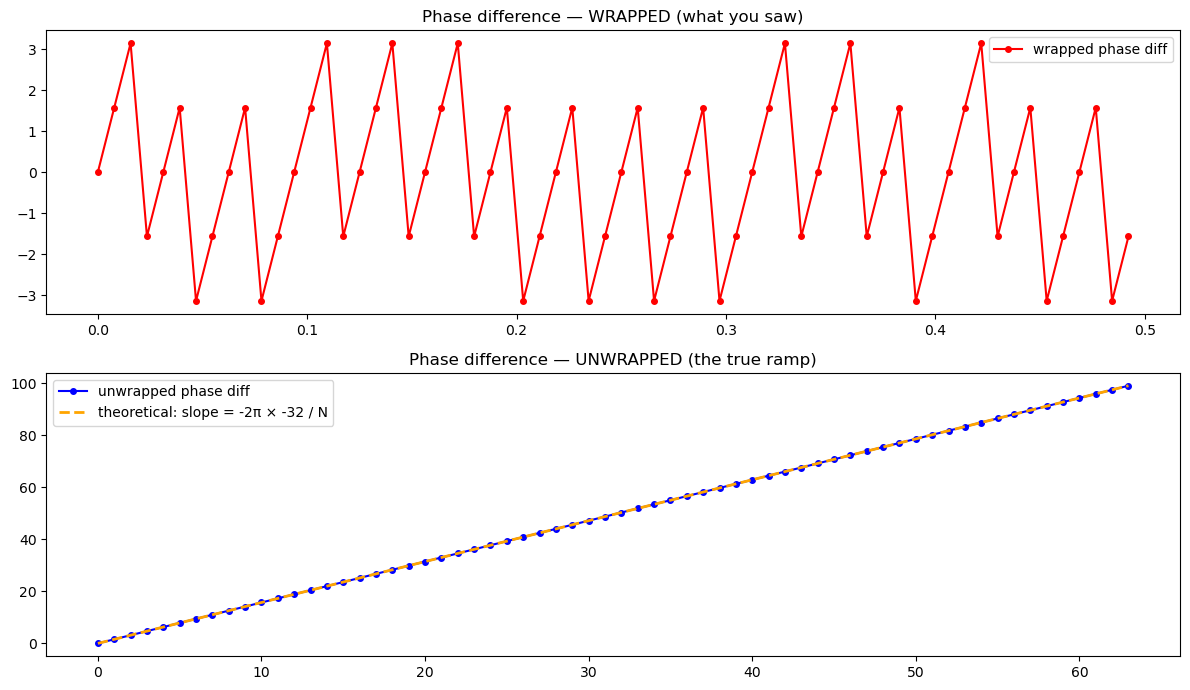

In [70]:
N = 128
t = np.arange(N)
signal = np.sin(2 * np.pi * 3 * t / N) + 0.5 * np.sin(2 * np.pi * 7 * t / N)

shift = -32
signal_shifted = np.roll(signal, shift)

F1 = np.fft.fft(signal)
F2 = np.fft.fft(signal_shifted)
freqs = np.fft.fftfreq(N)

phase_diff = np.angle(F2 * np.conj(F1))
phase_diff_unwrapped = np.unwrap(phase_diff)

# The theoretical line: slope should be exactly -2pi * shift / N
theoretical = -2 * np.pi * shift * np.arange(N) / N

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(freqs[:N//2], phase_diff[:N//2], 'o-', color='red', markersize=4, label='wrapped phase diff')
axes[0].set_title('Phase difference — WRAPPED (what you saw)')
axes[0].legend()

axes[1].plot(phase_diff_unwrapped[:N//2], 'o-', color='blue', markersize=4, label='unwrapped phase diff')
axes[1].plot(theoretical[:N//2], '--', color='orange', linewidth=2, label=f'theoretical: slope = -2π × {shift} / N')
axes[1].set_title('Phase difference — UNWRAPPED (the true ramp)')
axes[1].legend()

plt.tight_layout()
plt.show()